# Road Network Extraction — Sentinel-2 Imagery  
**Model:** UNet++ / EfficientNet-B4 / scSE Attention ← upgraded from DeepLabV3+  
**Training:** Single T4 GPU · AMP fp16 · Gradient Clipping · OneCycleLR  
**Dataset:** ISRO Sentinel-2 — 5,634 samples @ 256×256  



## Cell 1 — pip install

In [1]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.4 MB/s eta 0:00:00


## Cell 2 — Imports

In [2]:
import os, json, warnings, gc
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import albumentations as A
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import segmentation_models_pytorch as smp

from torch.utils.checkpoint import checkpoint_sequential

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## Cell 3 — GPU Setup

In [3]:
# ── GPU setup — single cuda:0, no DataParallel ────────────────────────────
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()

print(f'Device : {device}')
print(f'GPUs   : {n_gpus}')
for i in range(n_gpus):
    mem = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}  ({mem:.1f} GB)')

# AMP only on Volta/Turing+ (sm_70+) — T4 is sm_75 ✅
USE_AMP = (torch.cuda.is_available() and
           torch.cuda.get_device_capability(0)[0] >= 7)
print(f'AMP (fp16) : {USE_AMP}')
print(f'Compute cap: {torch.cuda.get_device_capability(0) if torch.cuda.is_available() else "N/A"}')

Device : cuda:0
GPUs   : 2
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)
AMP (fp16) : True
Compute cap: (7, 5)


## Cell 4 — Config & Hyperparameters

In [4]:
IMAGE_DIR = '/kaggle/input/datasets/sonisuyash/sentinel-2-roads-dataset/15765738/images_enhanced_png/images_enhanced_png'
MASK_DIR  = '/kaggle/input/datasets/sonisuyash/sentinel-2-roads-dataset/15765738/masks_png/masks_png'
CKPT_PATH = '/kaggle/working/best_road_model_unetpp_v4.pth'  # ← v4

BATCH_SIZE   = 16
NUM_WORKERS  = 2
EPOCHS       = 70       # ← up from 60, model needs more time with elastic aug
THRESHOLD    = 0.600
PATIENCE     = 12       # ← up from 10, give more room before early stopping
ES_MIN_DELTA = 5e-4
GRAD_CLIP    = 1.0

import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

print(f'BATCH_SIZE : {BATCH_SIZE}')
print(f'EPOCHS     : {EPOCHS}')
print(f'PATIENCE   : {PATIENCE}')
print(f'CKPT_PATH  : {CKPT_PATH}')

BATCH_SIZE : 16
EPOCHS     : 70
PATIENCE   : 12
CKPT_PATH  : /kaggle/working/best_road_model_unetpp_v4.pth


## Cell 5 — Data Splits

In [5]:
image_ids = sorted(os.listdir(IMAGE_DIR))
print(f'Total samples : {len(image_ids)}')

train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=42)
val_ids,  test_ids = train_test_split(val_ids,   test_size=0.5, random_state=42)
print(f'Train : {len(train_ids)} | Val : {len(val_ids)} | Test : {len(test_ids)}')

Total samples : 5634
Train : 4507 | Val : 563 | Test : 564


## Cell 6 — Augmentation

In [6]:
# ── Identical to v1 — already strong, but added Elastic Transform and Grid Distortion─────────────────
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2),
    A.ElasticTransform(alpha=1, sigma=10, p=0.2),        # ← reduced from 0.3
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.2),  # ← reduced from 0.3
])
val_transform = A.Compose([])
print('Augmentation pipelines ready')

Augmentation pipelines ready


## Cell 7 — Dataset Class

In [7]:
class RoadDataset(Dataset):
    def __init__(self, ids, img_dir, mask_dir, transform=None):
        self.ids       = ids
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img  = cv2.cvtColor(
            cv2.imread(os.path.join(self.img_dir, self.ids[idx])),
            cv2.COLOR_BGR2RGB)
        mask = cv2.imread(
            os.path.join(self.mask_dir, self.ids[idx]),
            cv2.IMREAD_GRAYSCALE)

        img  = img.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)   # hard binary, no interpolation
        mask = np.expand_dims(mask, -1)

        if self.transform:
            aug        = self.transform(image=img, mask=mask)
            img, mask  = aug['image'], aug['mask']

        img  = np.transpose(img,  (2, 0, 1)).astype('float32')
        mask = np.transpose(mask, (2, 0, 1)).astype('float32')
        return torch.tensor(img), torch.tensor(mask)


train_ds = RoadDataset(train_ids, IMAGE_DIR, MASK_DIR, train_transform)
val_ds   = RoadDataset(val_ids,   IMAGE_DIR, MASK_DIR, val_transform)
test_ds  = RoadDataset(test_ids,  IMAGE_DIR, MASK_DIR, val_transform)

print(f'Train : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}')

Train : 4507 | Val : 563 | Test : 564


## Cell 8 — DataLoaders

In [8]:
# ── Safe config for Kaggle T4 — persistent_workers=False prevents RAM OOM ─
def make_loader(ds, shuffle):
    return DataLoader(
        ds,
        batch_size         = BATCH_SIZE,
        shuffle            = shuffle,
        num_workers        = NUM_WORKERS,
        pin_memory         = True,
        persistent_workers = False,   # OFF — causes RAM exhaustion on Kaggle
        prefetch_factor    = 2,
        drop_last          = shuffle,
    )

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 281
Val batches   : 36
Test batches  : 36


## Cell 9 — Model: UNet++ + EfficientNet-B4 + scSE Attention

### UNet++ vs DeepLabV3+
| Feature | DeepLabV3+ (v1) | UNet++ (v2) |
|---|---|---|
| Skip connections | Single encoder→decoder | Dense nested (re-uses all scales) |
| Thin road recovery | ASPP only | scSE spatial attention focuses on thin pixels |
| Multi-scale context | Atrous convolutions | Nested dense blocks at every scale |
| FP reduction | Moderate | Better — attention gates suppress background |

### scSE = Squeeze & Excitation (channel) + Spatial Squeeze & Excitation
- **Channel SE**: learns *which feature maps* matter for roads  
- **Spatial SE**: learns *where* in the image to pay attention  
- Combined → model learns to suppress false positives from vegetation/buildings

In [9]:
# ── Delete old model from GPU 0 before loading new one ────────────────────
try:
    del model
    print('Old model deleted')
except NameError:
    print('No previous model found')

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f'GPU 0 free : {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB')
print(f'GPU 1 free : {torch.cuda.mem_get_info(1)[0]/1e9:.2f} GB')

# ── Switch to GPU 1 — it has 15GB free vs GPU 0's fragmented ~1.8MB ───────
device = torch.device('cuda:1')
print(f'Device switched to : {device}')

# ── Also move loss tensors to new device ──────────────────────────────────
bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([12.0]).to(device))

def build_model():
    model = smp.UnetPlusPlus(
        encoder_name           = 'efficientnet-b4',
        encoder_weights        = 'imagenet',
        decoder_attention_type = 'scse',
        in_channels            = 3,
        classes                = 1,
        activation             = None,
    )
    try:
        model.encoder.model.set_grad_checkpointing(True)
        print('Gradient checkpointing : ON (timm path)')
    except AttributeError:
        for block in model.encoder.modules():
            if hasattr(block, 'gradient_checkpointing'):
                block.gradient_checkpointing = True
        print('Gradient checkpointing : ON (manual block fallback)')
    return model

model = build_model().to(device)

gc.collect()
torch.cuda.empty_cache()

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params          : {total_params:,}')
print(f'Trainable params      : {train_params:,}')
print(f'GPU 0 free after load : {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB')
print(f'GPU 1 free after load : {torch.cuda.mem_get_info(1)[0]/1e9:.2f} GB')

No previous model found
GPU 0 free : 15.53 GB
GPU 1 free : 15.53 GB
Device switched to : cuda:1


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Gradient checkpointing : ON (manual block fallback)
Total params          : 20,924,428
Trainable params      : 20,924,428
GPU 0 free after load : 15.53 GB
GPU 1 free after load : 15.43 GB


## Cell 10 — Loss Function

Same combined loss as v1 — proven effective for 160:1 class imbalance.

In [10]:
# ── Loss components ────────────────────────────────────────────────────────
# Road pixels ≈ 0.6% of all pixels → Background:Road ≈ 160:1
# pos_weight=16.0 corrects for this imbalance in BCE (before pos_weight was 12)
bce_loss   = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([12.0]).to(device))  # ← reverted from 16.0
dice_loss  = smp.losses.DiceLoss(mode='binary')
focal_loss = smp.losses.FocalLoss(mode='binary', alpha=0.85, gamma=3.0)

def combined_loss(pred, target):
    """
    Weighted combination:
      0.5 * Dice  — optimizes overlap directly (robust to imbalance)
      0.4 * Focal — gamma=3 downweights easy background, focuses on hard road pixels
      0.1 * BCE   — pos_weight=12 corrects class frequency imbalance
    """
    return (0.5 * dice_loss(pred, target)
          + 0.4 * focal_loss(pred, target)
          + 0.1 * bce_loss(pred, target))

print('Loss function ready')
print('  Dice  weight : 0.5')
print('  Focal weight : 0.4  (alpha=0.85, gamma=3.0)')
print('  BCE   weight : 0.1  (pos_weight=12.0)') # reverted back to 12

Loss function ready
  Dice  weight : 0.5
  Focal weight : 0.4  (alpha=0.85, gamma=3.0)
  BCE   weight : 0.1  (pos_weight=12.0)


## Cell 11 — Optimizer & Scheduler

In [11]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-4,
    weight_decay = 2e-4,
    eps          = 1e-7,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr           = 3e-4,    # ← reduced from 4e-4, slower peak = longer exploration
    epochs           = EPOCHS,
    steps_per_epoch  = len(train_loader),
    pct_start        = 0.3,
    anneal_strategy  = 'cos',
    div_factor       = 10,
    final_div_factor = 100,
)

scaler = GradScaler(enabled=USE_AMP)

print('Optimizer  : AdamW  (lr=1e-4, wd=2e-4)')
print('Scheduler  : OneCycleLR  (max_lr=3e-4, per-batch)')  # ← updated
print(f'GradScaler : enabled={USE_AMP}')

Optimizer  : AdamW  (lr=1e-4, wd=2e-4)
Scheduler  : OneCycleLR  (max_lr=3e-4, per-batch)
GradScaler : enabled=True


## Cell 12 — Metrics

In [12]:
def get_metrics(pred, target):
    """Compute IoU, Dice, Precision, Recall, F1 from raw logits."""
    pred_b = (torch.sigmoid(pred) > THRESHOLD).float()
    TP = (pred_b * target).sum()
    FP = (pred_b * (1 - target)).sum()
    FN = ((1 - pred_b) * target).sum()
    iou  = (TP + 1e-7) / (TP + FP + FN + 1e-7)
    dice = (2*TP + 1e-7) / (2*TP + FP + FN + 1e-7)
    prec = (TP + 1e-7) / (TP + FP + 1e-7)
    rec  = (TP + 1e-7) / (TP + FN + 1e-7)
    f1   = (2 * prec * rec) / (prec + rec + 1e-7)
    return iou.item(), dice.item(), prec.item(), rec.item(), f1.item()


def evaluate(mdl, loader):
    """Run full evaluation pass on a DataLoader. Returns dict of avg metrics."""
    mdl.eval()
    totals = dict(loss=0, iou=0, dice=0, prec=0, rec=0, f1=0)
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with autocast(enabled=USE_AMP):
                preds = mdl(imgs)
                totals['loss'] += combined_loss(preds, masks).item()
            iou, dice, prec, rec, f1 = get_metrics(preds.float(), masks)
            totals['iou']  += iou
            totals['dice'] += dice
            totals['prec'] += prec
            totals['rec']  += rec
            totals['f1']   += f1
    n = len(loader)
    return {k: v / n for k, v in totals.items()}

print('Metrics functions ready')

Metrics functions ready


## Cell 13 — Training Loop

In [13]:
import torch, gc

history = {'train_loss': [], 'val_loss': [], 'val_iou': [],
           'val_dice': [], 'val_f1': [], 'val_prec': [], 'val_rec': []}

best_val_iou   = 0.0
patience_count = 0

# ── Clear any leftover memory before starting ──────────────────────────────
gc.collect()
torch.cuda.empty_cache()

print(f'Starting training — {EPOCHS} epochs max, early stop patience={PATIENCE}')
print(f'Gradient clipping : max_norm={GRAD_CLIP}')
print(f'GPU memory free   : {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch:02d} train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad(set_to_none=True)   # ← set_to_none=True frees grad memory immediately

        with autocast(enabled=USE_AMP):
            preds = model(imgs)
            loss  = combined_loss(preds, masks)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── Clear cache before validation pass ────────────────────────────────
    gc.collect()
    torch.cuda.empty_cache()

    # ── Validate ───────────────────────────────────────────────────────────
    val_m = evaluate(model, val_loader)

    # ── Log ────────────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_m['loss'])
    history['val_iou'].append(val_m['iou'])
    history['val_dice'].append(val_m['dice'])
    history['val_f1'].append(val_m['f1'])
    history['val_prec'].append(val_m['prec'])
    history['val_rec'].append(val_m['rec'])

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Ep {epoch:02d}/{EPOCHS}  "
          f"TrainLoss={train_loss:.4f}  "
          f"ValLoss={val_m['loss']:.4f}  "
          f"IoU={val_m['iou']:.4f}  "
          f"F1={val_m['f1']:.4f}  "
          f"Prec={val_m['prec']:.4f}  "
          f"Rec={val_m['rec']:.4f}  "
          f"LR={current_lr:.2e}")

    # ── Checkpoint ─────────────────────────────────────────────────────────
    if val_m['iou'] > best_val_iou + ES_MIN_DELTA:
        best_val_iou   = val_m['iou']
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  ✅ New best IoU {best_val_iou:.4f} — checkpoint saved')
    else:
        patience_count += 1
        print(f'  ⏳ No improvement ({patience_count}/{PATIENCE})')

    # ── Early stopping ─────────────────────────────────────────────────────
    if patience_count >= PATIENCE:
        print(f'\n🛑 Early stopping at epoch {epoch} — best IoU {best_val_iou:.4f}')
        break

print('\nTraining complete.')
print(f'Best Val IoU : {best_val_iou:.4f}')

Starting training — 70 epochs max, early stop patience=12
Gradient clipping : max_norm=1.0
GPU memory free   : 15.53 GB


Ep 01/70  TrainLoss=0.5790  ValLoss=0.5549  IoU=0.0000  F1=0.0000  Prec=0.9167  Rec=0.0000  LR=3.15e-05
  ⏳ No improvement (1/12)


Ep 02/70  TrainLoss=0.5468  ValLoss=0.5355  IoU=0.0000  F1=0.0000  Prec=0.4445  Rec=0.0000  LR=3.60e-05
  ⏳ No improvement (2/12)


Ep 03/70  TrainLoss=0.5304  ValLoss=0.5207  IoU=0.0641  F1=0.1195  Prec=0.2683  Rec=0.0786  LR=4.34e-05
  ✅ New best IoU 0.0641 — checkpoint saved


Ep 04/70  TrainLoss=0.5160  ValLoss=0.5025  IoU=0.1205  F1=0.2143  Prec=0.1369  Rec=0.5053  LR=5.35e-05
  ✅ New best IoU 0.1205 — checkpoint saved


...

Ep 66/70  TrainLoss=0.2907  ValLoss=0.2723  IoU=0.3442  F1=0.5113  Prec=0.4214  Rec=0.6545  LR=5.19e-06
  ⏳ No improvement (6/12)


Ep 67/70  TrainLoss=0.2881  ValLoss=0.2717  IoU=0.3461  F1=0.5133  Prec=0.4299  Rec=0.6412  LR=3.06e-06
  ⏳ No improvement (7/12)


Ep 68/70  TrainLoss=0.2896  ValLoss=0.2723  IoU=0.3448  F1=0.5119  Prec=0.4266  Rec=0.6442  LR=1.53e-06
  ⏳ No improvement (8/12)


Ep 69/70  TrainLoss=0.2921  ValLoss=0.2727  IoU=0.3439  F1=0.5109  Prec=0.4225  Rec=0.6506  LR=6.06e-07
  ⏳ No improvement (9/12)


Ep 70/70  TrainLoss=0.2879  ValLoss=0.2727  IoU=0.3439  F1=0.5109  Prec=0.4217  Rec=0.6525  LR=3.00e-07
  ⏳ No improvement (10/12)

Training complete.
Best Val IoU : 0.3461


## Cell 14 — Loss / Metric Curves

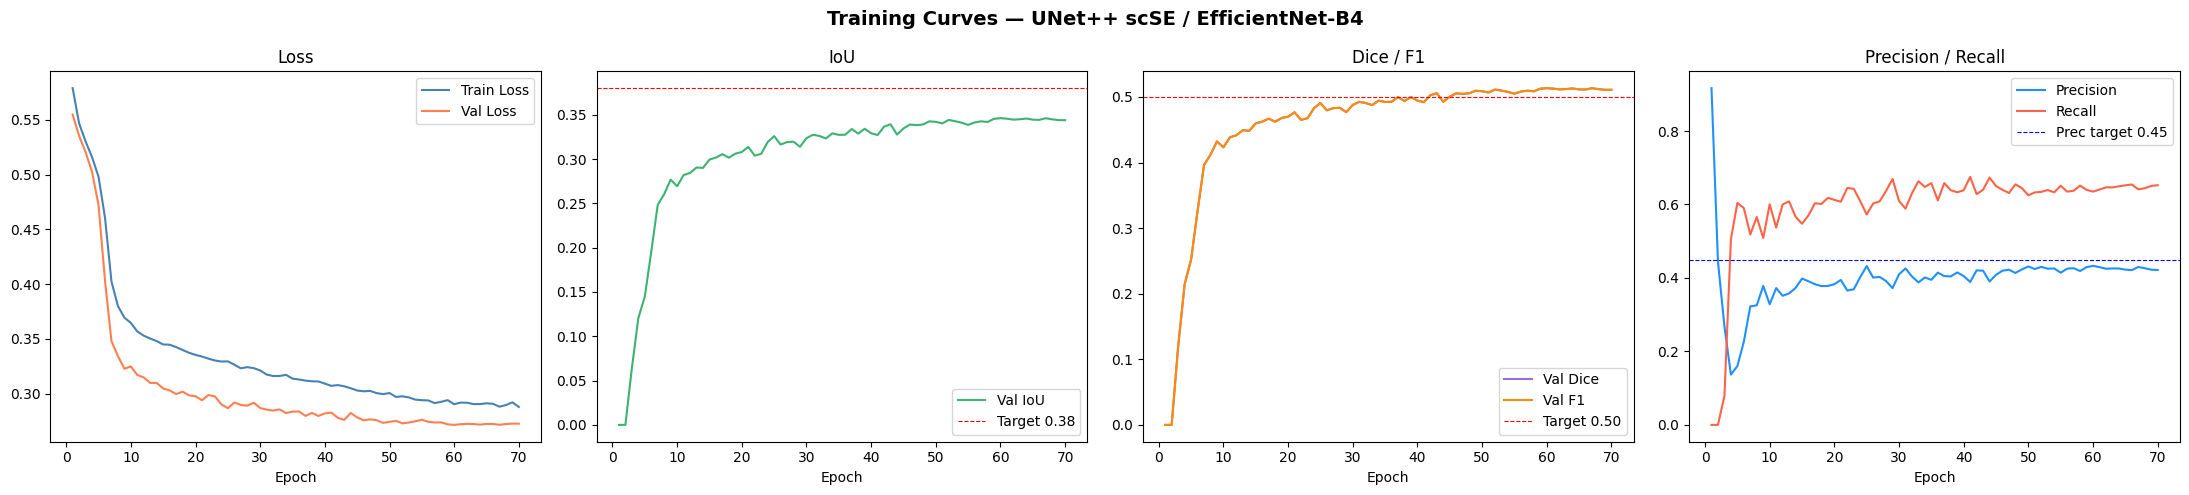

Saved: viz_loss_curves.png


In [14]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Training Curves — UNet++ scSE / EfficientNet-B4', fontsize=14, fontweight='bold')

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_ran, history['val_iou'],  label='Val IoU',  color='mediumseagreen')
axes[1].axhline(0.38, color='red', linestyle='--', linewidth=0.8, label='Target 0.38')
axes[1].set_title('IoU'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_ran, history['val_dice'], label='Val Dice', color='mediumpurple')
axes[2].plot(epochs_ran, history['val_f1'],   label='Val F1',   color='darkorange')
axes[2].axhline(0.50, color='red', linestyle='--', linewidth=0.8, label='Target 0.50')
axes[2].set_title('Dice / F1'); axes[2].legend(); axes[2].set_xlabel('Epoch')

axes[3].plot(epochs_ran, history['val_prec'], label='Precision', color='dodgerblue')
axes[3].plot(epochs_ran, history['val_rec'],  label='Recall',    color='tomato')
axes[3].axhline(0.45, color='blue', linestyle='--', linewidth=0.8, label='Prec target 0.45')
axes[3].set_title('Precision / Recall'); axes[3].legend(); axes[3].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_loss_curves.png')

## Cell 15 — Threshold Search

Sweeps thresholds from 0.20 to 0.60 on the **validation set** to find the F1-optimal cutoff. Run this after training completes.

In [15]:
# ── Load best checkpoint for threshold search ──────────────────────────────
thresh_model = build_model().to(device)
thresh_model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
thresh_model.eval()

# ── Collect all val logits in one pass ────────────────────────────────────
all_logits, all_masks = [], []
with torch.no_grad():
    for imgs, masks in tqdm(val_loader, desc='Collecting val logits'):
        with autocast(enabled=USE_AMP):
            logits = thresh_model(imgs.to(device))
        all_logits.append(torch.sigmoid(logits.float()).cpu())
        all_masks.append(masks.cpu())

all_logits = torch.cat(all_logits)  # (N, 1, H, W)
all_masks  = torch.cat(all_masks)   # (N, 1, H, W)

# ── Sweep thresholds ───────────────────────────────────────────────────────
thresholds  = np.arange(0.20, 0.61, 0.025)
best_f1     = 0.0
best_thresh = 0.35
results     = []

for t in thresholds:
    preds_b = (all_logits > t).float()
    TP = (preds_b * all_masks).sum()
    FP = (preds_b * (1 - all_masks)).sum()
    FN = ((1 - preds_b) * all_masks).sum()
    prec = (TP + 1e-7) / (TP + FP + 1e-7)
    rec  = (TP + 1e-7) / (TP + FN + 1e-7)
    f1   = (2 * prec * rec) / (prec + rec + 1e-7)
    iou  = (TP + 1e-7) / (TP + FP + FN + 1e-7)
    results.append((t, f1.item(), iou.item(), prec.item(), rec.item()))
    if f1 > best_f1:
        best_f1     = f1.item()
        best_thresh = t

print(f'\n{"Thresh":>8}  {"F1":>8}  {"IoU":>8}  {"Prec":>8}  {"Rec":>8}')
for t, f1, iou, prec, rec in results:
    marker = ' ← best' if abs(t - best_thresh) < 0.001 else ''
    print(f'{t:8.3f}  {f1:8.4f}  {iou:8.4f}  {prec:8.4f}  {rec:8.4f}{marker}')

print(f'\n✅ Best threshold : {best_thresh:.3f}  (F1 = {best_f1:.4f})')
THRESHOLD = best_thresh  # update global threshold for inference cells below

Gradient checkpointing : ON (manual block fallback)



  Thresh        F1       IoU      Prec       Rec
   0.200    0.5037    0.3366    0.3984    0.6845
   0.225    0.5050    0.3378    0.4014    0.6804
   0.250    0.5060    0.3387    0.4041    0.6765
   0.275    0.5070    0.3396    0.4066    0.6731
   0.300    0.5078    0.3403    0.4090    0.6696
   0.325    0.5086    0.3410    0.4111    0.6666
   0.350    0.5091    0.3415    0.4132    0.6632
   0.375    0.5098    0.3421    0.4152    0.6603
   0.400    0.5103    0.3426    0.4171    0.6572
   0.425    0.5109    0.3431    0.4190    0.6544
   0.450    0.5116    0.3437    0.4211    0.6518
   0.475    0.5119    0.3440    0.4228    0.6488
   0.500    0.5123    0.3444    0.4245    0.6460
   0.525    0.5127    0.3447    0.4263    0.6430
   0.550    0.5130    0.3450    0.4280    0.6401
   0.575    0.5134    0.3453    0.4299    0.6371
   0.600    0.5137    0.3456    0.4317    0.6341 ← best

✅ Best threshold : 0.600  (F1 = 0.5137)


## Cell 16 — Load Best Checkpoint for Inference

In [16]:
def tta_predict(mdl, imgs, threshold):
    """
    Average predictions across 4 augmentation versions:
    original, hflip, vflip, hflip+vflip
    Helps recover thin roads the model is borderline on.
    """
    with torch.no_grad():
        imgs = imgs.to(device)

        with autocast(enabled=USE_AMP):
            p_orig  = torch.sigmoid(mdl(imgs).float())
            p_hflip = torch.sigmoid(mdl(torch.flip(imgs, dims=[3])).float())
            p_vflip = torch.sigmoid(mdl(torch.flip(imgs, dims=[2])).float())
            p_both  = torch.sigmoid(mdl(torch.flip(imgs, dims=[2, 3])).float())

        # Flip predictions back to original orientation before averaging
        p_hflip = torch.flip(p_hflip, dims=[3])
        p_vflip = torch.flip(p_vflip, dims=[2])
        p_both  = torch.flip(p_both,  dims=[2, 3])

        avg = (p_orig + p_hflip + p_vflip + p_both) / 4.0

    return (avg > threshold).float()


def evaluate_tta(mdl, loader):
    mdl.eval()
    totals = dict(iou=0, dice=0, prec=0, rec=0, f1=0)
    with torch.no_grad():
        for imgs, masks in loader:
            masks = masks.to(device)
            preds_b = tta_predict(mdl, imgs, THRESHOLD)

            TP = (preds_b * masks).sum()
            FP = (preds_b * (1 - masks)).sum()
            FN = ((1 - preds_b) * masks).sum()
            iou  = (TP + 1e-7) / (TP + FP + FN + 1e-7)
            dice = (2*TP + 1e-7) / (2*TP + FP + FN + 1e-7)
            prec = (TP + 1e-7) / (TP + FP + 1e-7)
            rec  = (TP + 1e-7) / (TP + FN + 1e-7)
            f1   = (2 * prec * rec) / (prec + rec + 1e-7)
            totals['iou']  += iou.item()
            totals['dice'] += dice.item()
            totals['prec'] += prec.item()
            totals['rec']  += rec.item()
            totals['f1']   += f1.item()

    n = len(loader)
    return {k: v / n for k, v in totals.items()}



inference_model = build_model().to(device)
inference_model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
inference_model.eval()
print(f'Checkpoint loaded — Best Val IoU : {best_val_iou:.4f}')
print(f'Active threshold  : {THRESHOLD}')
# # ── Run TTA evaluation on test set ────────────────────────────────────────
# inference_model.eval()
tta_metrics = evaluate_tta(inference_model, test_loader)

print('=' * 42)
print('   FINAL TEST METRICS — TTA @ threshold=0.60')
print('=' * 42)
for k, v in tta_metrics.items():
    print(f'  {k:<10}: {v:.4f}')
print('=' * 42)

Gradient checkpointing : ON (manual block fallback)
Checkpoint loaded — Best Val IoU : 0.3461
Active threshold  : 0.5999999999999999
   FINAL TEST METRICS — TTA @ threshold=0.60
  iou       : 0.3562
  dice      : 0.5238
  prec      : 0.4605
  rec       : 0.6147
  f1        : 0.5238


## Cell 17 — Prediction Comparison (Image | GT | Prediction)

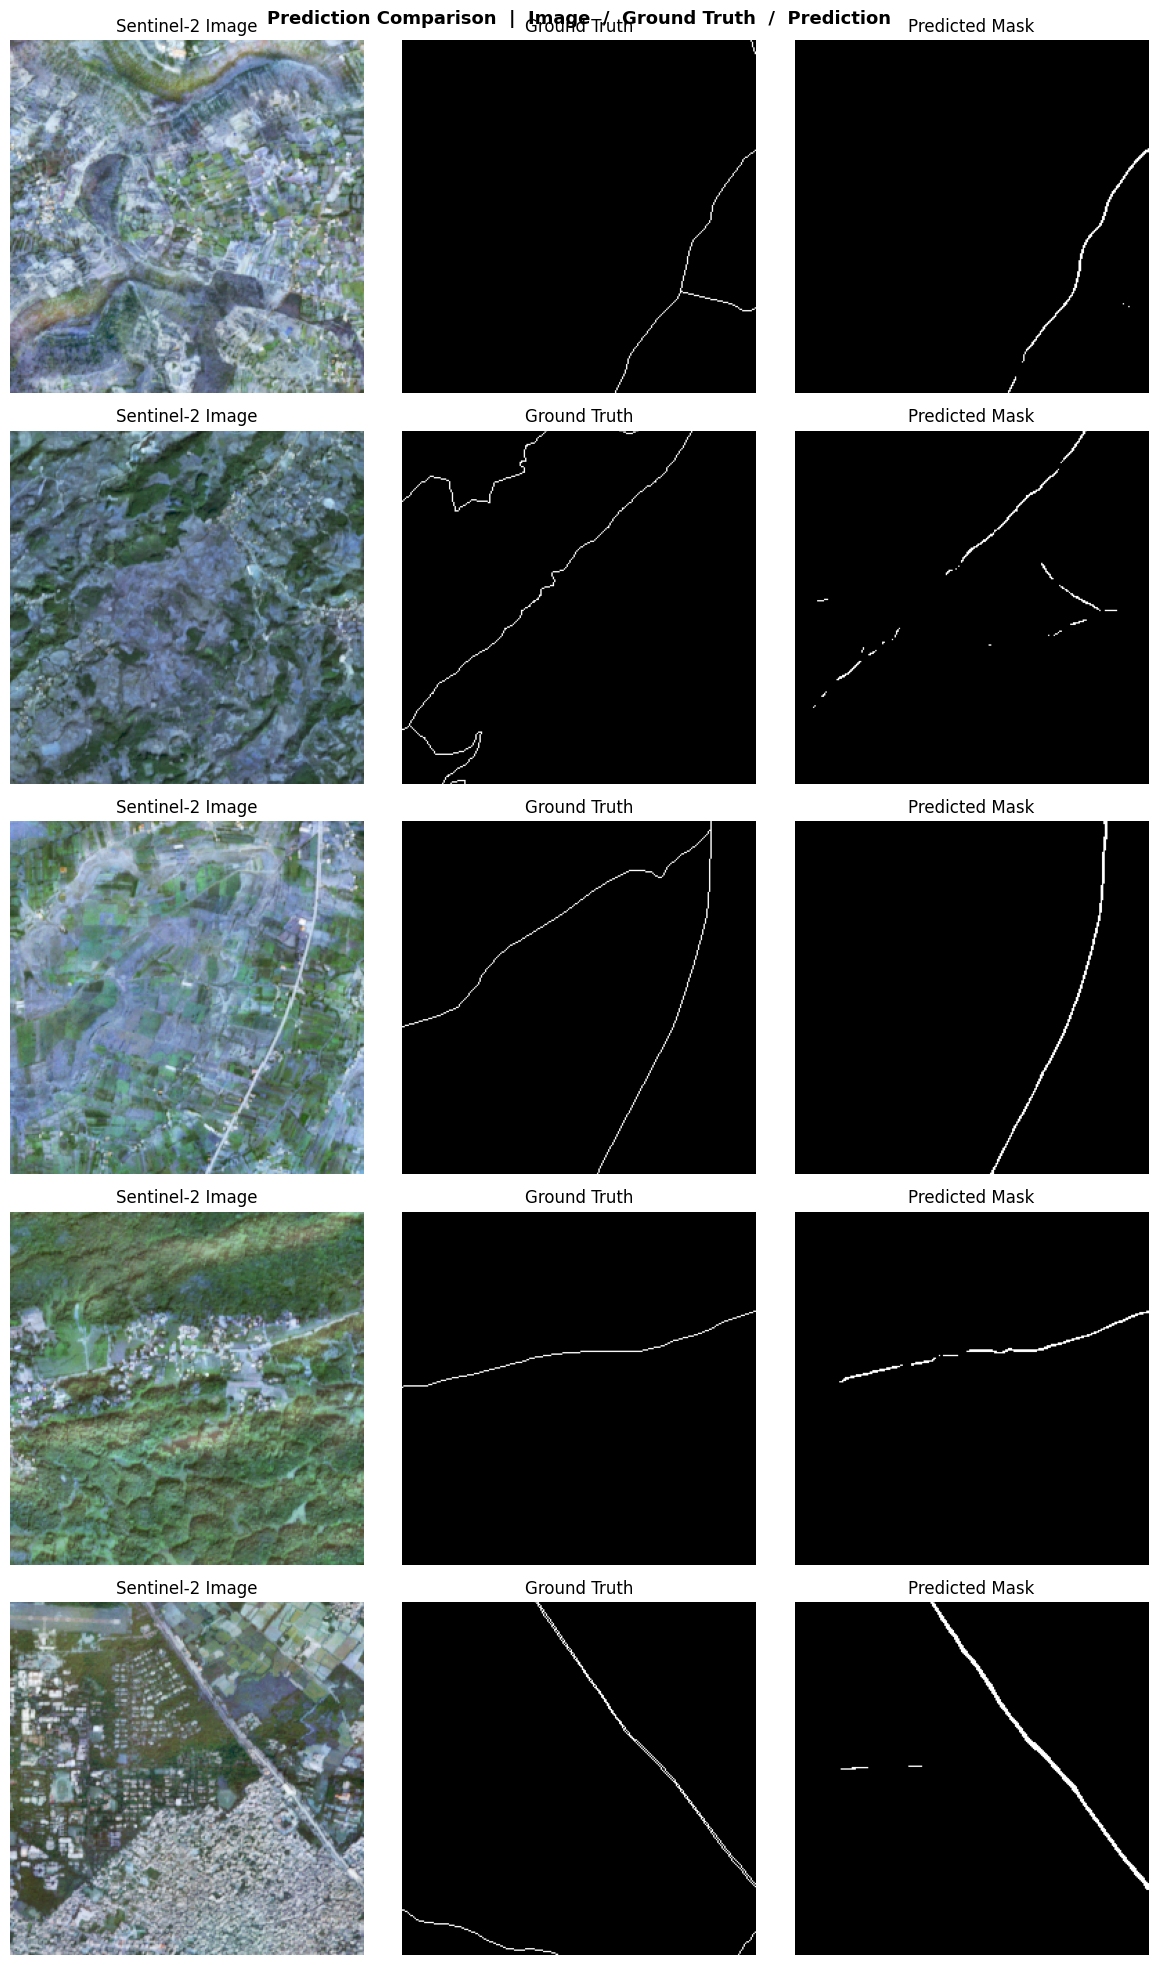

Saved: viz_prediction_comparison.png


In [17]:
def denorm(t):
    arr = t.permute(1, 2, 0).cpu().numpy()
    return (arr * 255).clip(0, 255).astype(np.uint8)

imgs_b, masks_b = next(iter(test_loader))
with torch.no_grad():
    with autocast(enabled=USE_AMP):
        preds_b = inference_model(imgs_b.to(device))
    preds_b = (torch.sigmoid(preds_b.float()) > THRESHOLD).float().cpu()

N = 5
fig, axes = plt.subplots(N, 3, figsize=(12, N * 4))
fig.suptitle('Prediction Comparison  |  Image  /  Ground Truth  /  Prediction',
             fontsize=13, fontweight='bold')

for i in range(N):
    for ax, data, title, cmap in zip(
        axes[i],
        [denorm(imgs_b[i]), masks_b[i][0].numpy(), preds_b[i][0].numpy()],
        ['Sentinel-2 Image', 'Ground Truth', 'Predicted Mask'],
        [None, 'gray', 'gray']
    ):
        ax.imshow(data, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_prediction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_prediction_comparison.png')

## Cell 18 — Overlay Visualization (TP / FP / FN)

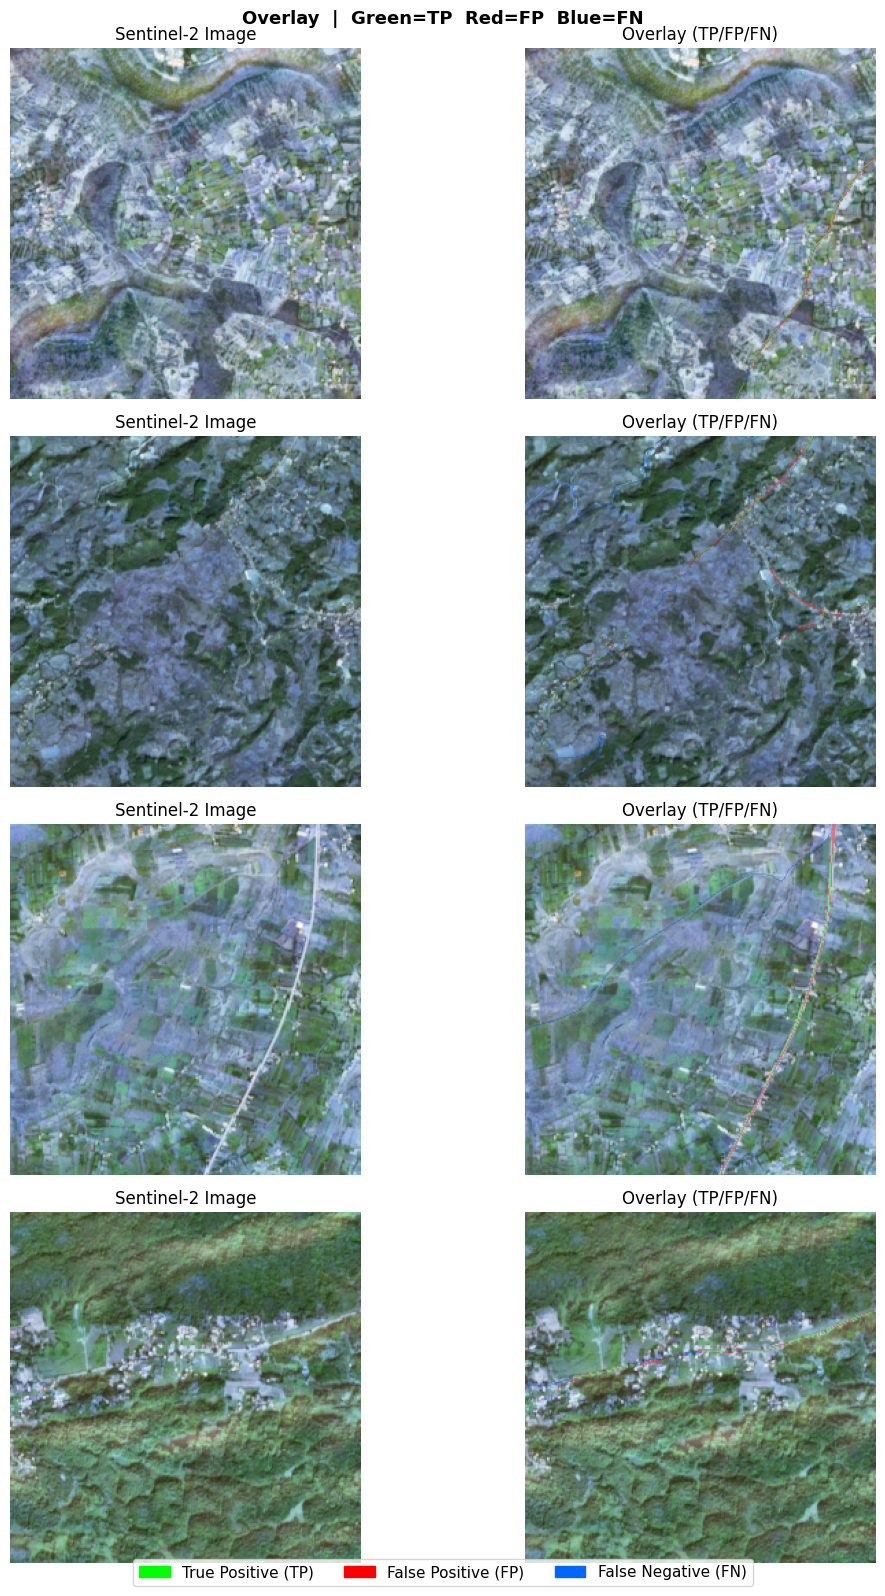

Saved: viz_overlay.png


In [18]:
def make_overlay(image_rgb, pred_mask, gt_mask, alpha=0.45):
    overlay = image_rgb.copy().astype(np.float32)
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    overlay[pred & gt]   = overlay[pred & gt]   * (1-alpha) + np.array([0,   255, 0],   np.float32) * alpha  # TP green
    overlay[pred & ~gt]  = overlay[pred & ~gt]  * (1-alpha) + np.array([255, 0,   0],   np.float32) * alpha  # FP red
    overlay[~pred & gt]  = overlay[~pred & gt]  * (1-alpha) + np.array([0,   100, 255], np.float32) * alpha  # FN blue
    return overlay.clip(0, 255).astype(np.uint8)

N = 4
fig, axes = plt.subplots(N, 2, figsize=(12, N * 4))
fig.suptitle('Overlay  |  Green=TP  Red=FP  Blue=FN', fontsize=13, fontweight='bold')

for i in range(N):
    img_np  = denorm(imgs_b[i])
    overlay = make_overlay(img_np, preds_b[i][0].numpy(), masks_b[i][0].numpy())
    axes[i, 0].imshow(img_np);  axes[i, 0].set_title('Sentinel-2 Image');   axes[i, 0].axis('off')
    axes[i, 1].imshow(overlay); axes[i, 1].set_title('Overlay (TP/FP/FN)'); axes[i, 1].axis('off')

legend_patches = [
    mpatches.Patch(color=(0, 1, 0),   label='True Positive (TP)'),
    mpatches.Patch(color=(1, 0, 0),   label='False Positive (FP)'),
    mpatches.Patch(color=(0, 0.4, 1), label='False Negative (FN)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.savefig('/kaggle/working/viz_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_overlay.png')

## Cell 19 — Pixel-Level Confusion Matrix

Confusion matrix: 100%|██████████| 36/36 [00:05<00:00,  6.23it/s]


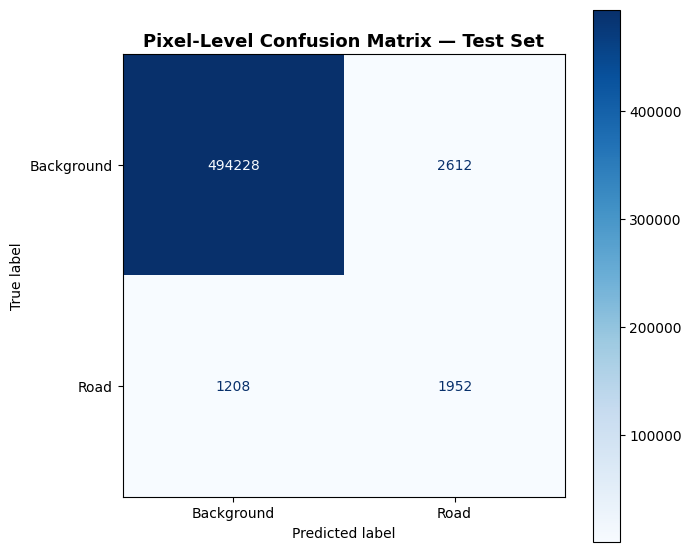

Pixel Accuracy : 0.9924
Road IoU       : 0.3382
Precision      : 0.4277
Recall         : 0.6177
F1 Score       : 0.5054
Saved: viz_confusion_matrix.png


In [19]:
all_preds_flat, all_gts_flat = [], []

inference_model.eval()
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Confusion matrix'):
        with autocast(enabled=USE_AMP):
            preds = inference_model(imgs.to(device))
        preds = (torch.sigmoid(preds.float()) > THRESHOLD).float().cpu()
        all_preds_flat.append(preds.numpy().flatten())
        all_gts_flat.append(masks.numpy().flatten())

all_preds_flat = np.concatenate(all_preds_flat).astype(int)
all_gts_flat   = np.concatenate(all_gts_flat).astype(int)

# subsample for display speed — full set is ~370M pixels
idx = np.random.choice(len(all_preds_flat),
                        size=min(500_000, len(all_preds_flat)),
                        replace=False)
cm  = confusion_matrix(all_gts_flat[idx], all_preds_flat[idx])

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=['Background', 'Road']).plot(
    ax=ax, cmap='Blues', colorbar=True, values_format='d')
ax.set_title('Pixel-Level Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/viz_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

TN, FP, FN, TP = cm.ravel()
pixel_acc = (TP + TN) / (TP + TN + FP + FN)
iou_road  = TP / (TP + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)

print(f'Pixel Accuracy : {pixel_acc:.4f}')
print(f'Road IoU       : {iou_road:.4f}')
print(f'Precision      : {precision:.4f}')
print(f'Recall         : {recall:.4f}')
print(f'F1 Score       : {f1:.4f}')
print('Saved: viz_confusion_matrix.png')

## Cell 20 — Final Test Set Evaluation

In [20]:
test_m = evaluate(inference_model, test_loader)

print('=' * 42)
print('      FINAL TEST SET METRICS — v2')
print('=' * 42)
for k, v in test_m.items():
    print(f'  {k:<10}: {v:.4f}')
print('=' * 42)

# ── vs v1 targets ─────────────────────────────────────────────────────────
print('\nTarget comparison:')
print(f'  F1   : {test_m["f1"]:.4f}  (target ≥ 0.50)')
print(f'  IoU  : {test_m["iou"]:.4f}  (target ≥ 0.38)')
print(f'  Prec : {test_m["prec"]:.4f}  (target ≥ 0.45)')
print(f'  Rec  : {test_m["rec"]:.4f}  (target 0.60–0.70)')

      FINAL TEST SET METRICS — v2
  loss      : 0.2703
  iou       : 0.3469
  dice      : 0.5136
  prec      : 0.4390
  rec       : 0.6259
  f1        : 0.5136

Target comparison:
  F1   : 0.5136  (target ≥ 0.50)
  IoU  : 0.3469  (target ≥ 0.38)
  Prec : 0.4390  (target ≥ 0.45)
  Rec  : 0.6259  (target 0.60–0.70)


## Cell 21 — Save & Zip Outputs

In [21]:
import zipfile
from datetime import datetime

with open('/kaggle/working/training_history.json', 'w') as f:
    json.dump(history, f)

files_to_save = [
    '/kaggle/working/best_road_model_unetpp_v4.pth',  # ← v4
    '/kaggle/working/training_history.json',
    '/kaggle/working/viz_loss_curves.png',
    '/kaggle/working/viz_prediction_comparison.png',
    '/kaggle/working/viz_overlay.png',
    '/kaggle/working/viz_confusion_matrix.png',
]

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
zip_path  = f'/kaggle/working/road_seg_v4_unetpp_{timestamp}.zip'  # ← v4

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath in files_to_save:
        if os.path.exists(fpath):
            zf.write(fpath, os.path.basename(fpath))
            print(f'  Added   : {os.path.basename(fpath)}')
        else:
            print(f'  MISSING : {fpath}')

zip_size = os.path.getsize(zip_path) / 1e6
print(f'\nZip saved : {zip_path}')
print(f'Zip size  : {zip_size:.1f} MB')
print(f'Download from: Output tab → {os.path.basename(zip_path)}')

  Added   : best_road_model_unetpp_v4.pth
  Added   : training_history.json
  Added   : viz_loss_curves.png
  Added   : viz_prediction_comparison.png
  Added   : viz_overlay.png
  Added   : viz_confusion_matrix.png

Zip saved : /kaggle/working/road_seg_v4_unetpp_20260413_1048.zip
Zip size  : 83.4 MB
Download from: Output tab → road_seg_v4_unetpp_20260413_1048.zip
